## Table of Contents
1. [The Brief](#the-brief)
2. [The Code](#the-code)
3. [Loading, Cleaning, and Joining](#0-loading-cleaning-joining)
4. [Normalise](#1-normalise)
5. [Building Functions](#3-build-functions)
6. [The Editorial](#the-editorial)

# The Brief:

> **Client:** Rolling Beats Magazine (music publication)
>
> **Your role:** Data Journalist
>
> **Context:** Rolling Beats is preparing their "25 Years of Pop" retrospective issue. The editorial team wants data-driven stories that reveal how popular music has evolved since 2000. They're looking for surprising trends, cultural shifts, and compelling visualizations that tell the story of modern pop.
>
> You have access to 25 years of Billboard Hot 100 chart data (2000-2024), combined with Spotify's audio analysis of each track.
>
> **Your task:** Explore 25 years of chart data and uncover the stories hidden within. What trends emerge? What has changed, and what has stayed the same? Find insights that would make readers say "I never knew that."

---
Creative Idea: Felix Weiland

Execution: Melina Torstensson

# The Code:

## 0 Loading, Cleaning, Joining


### import, checking the data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
tracks = pd.read_csv("RollingBeats_data/raw_tracks.csv")
chart_positions = pd.read_csv("RollingBeats_data/raw_chart_positions.csv")
artists = pd.read_csv("RollingBeats_data/raw_artists.csv")
mapping = pd.read_csv("RollingBeats_data/raw_mapping.csv")
audio_features = pd.read_csv("RollingBeats_data/raw_audio_feauters.csv")

In [3]:
type(tracks)

pandas.core.frame.DataFrame

#### getting an overview

In [4]:
tracks.head(5)

,track_id,name,duration_ms,release_date,album_type,explicit
0,6zeDYmP3ARpURvpK29Q09P,Someday,242800,1900-01-01,album,False
1,4T7fVN4ZOFE3JoGyaxZL6O,Falls Apart,255160,1900-01-01,album,False
2,5CMVGP24paZIukljDj0iWc,Jingle Bells (with The Ken Lane Singers),156666,1945,compilation,False
3,04vLj9QUXoKdRlsp3gkURo,Mele Kalikimaka (Merry Christmas),175333,1945-01-01,compilation,False
4,25leEEaz1gIpp7o21Fqyjo,Here Comes Santa Claus (Right Down Santa Claus...,150266,1947,album,False


In [5]:
chart_positions.head()

,chart_week,list_position,track_id
0,2021-07-10,42,000TJlEJQ3nafsm1hBWpoj
1,2003-07-19,60,003FTlCpBTM4eSqYSWPv4H
2,2003-07-26,60,003FTlCpBTM4eSqYSWPv4H
3,2003-08-02,64,003FTlCpBTM4eSqYSWPv4H
4,2003-07-12,66,003FTlCpBTM4eSqYSWPv4H


In [6]:
artists.head()

,artist_id,name,popularity,followers
0,13UwRaADQI0yTqjPBDkk6d,J-Shin (Featuring LaTocha Scott of Xscape),0,253
1,2LmsYeN3MzzZ9zhuZhNyqO,A*Teens,0,10
2,5Q25oFANw7zA3kD2DPaJ8D,The 2000s Karaoke Band,0,26
3,7u7ORV6MVjId1jfJwMdakL,2000s Karaoke Band,0,27
4,0LyfQWJT6nXafLPZqxe9Of,Various Artists,0,2542450


In [7]:
mapping.head()

,track_id,artist_id
0,00FQb4jTyendYWaN8pK0wa,4zmKGsrXjLmljb5fTaBTot
1,00FQb4jTyendYWaN8pK0wa,6GGtHZgBycCgGBUhZo81xe
2,00FQb4jTyendYWaN8pK0wa,22DH8NChecsgPxDjA4pqer
3,00FQb4jTyendYWaN8pK0wa,7JVNRVPeXFAOdMrxOHNjVv
4,00FQb4jTyendYWaN8pK0wa,24jvD83UgLmrdGjhWTFslY


In [8]:
audio_features.head()

,track_id,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 0.1 Clean first:

Strin clean function: lower all str, strip 
duplicates, string clean, check col names, check dt

want to change all to lower case, remove empty spaces before and after, remove double spaces, unfiy NaN
clean_df deals (table level) with the df on a higher level first, then we go deeper with
sting_cleaning (cell level) that deals with the text/str in the cols


#### cleaning function

In [9]:
# want to change all to lower case, remove empty spaces before and after, remove double spaces, unfiy NaN
# sting_cleaning (cell level) that deals with the text/str in the cols


def string_cleaning(text):
    # if the cell is not str - dont do anyting
    if pd.isna(text) or not isinstance(text, str): 
        return text    

    text = text.lower().strip()

    #split - divides words into separate 'cells' removes all excess spaces, join - and merge together again
    text = " ".join(text.split())

    return text


In [10]:
# clean_df (table level) deals with the df on a higher level first
# changes placeholders to Nan
# applies the string_clean function
# drops duplicates

def clean_df(df):
    placeholders = ['n/a', 'na', 'unknown', 'none', '-']

    df = df.replace(placeholders, np.nan)

    columns_with_string = df.select_dtypes(include=["object"]).columns

    for col in columns_with_string:
        df[col] = df[col].apply(string_cleaning)

    df = df.drop_duplicates().reset_index(drop=True)
    return df


#### tracks


In [11]:
tracks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11070 entries, 0 to 11069
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   track_id      11070 non-null  object
 1   name          11070 non-null  object
 2   duration_ms   11070 non-null  int64 
 3   release_date  11070 non-null  object
 4   album_type    11070 non-null  object
 5   explicit      11070 non-null  bool  
dtypes: bool(1), int64(1), object(4)
memory usage: 443.4+ KB


In [12]:
tracks = tracks.rename(columns={"name": "name_track"})

In [13]:
tracks_clean = clean_df(tracks)

tracks_clean.head(2)

,track_id,name_track,duration_ms,release_date,album_type,explicit
0,6zedymp3arpurvpk29q09p,someday,242800,1900-01-01,album,False
1,4t7fvn4zofe3jogyaxzl6o,falls apart,255160,1900-01-01,album,False


#### Changing unfinished dates eg yyyy or yyyy-mm 

Since some tracks had relese date YYYY or YYYY-MM I transformed them to YYYY-MM-DD by adding eiter '01-01' or '01'. I ddnt know if I woudl use this information yet, so for clarity i also added a flagging col naming them sort / medium / full. 

In [14]:
# just for bias safety, before changing dates i flagged them 

def funk_flag_release_date(date):
    length_date = len(date)
    
    if length_date <= 4:
        return "short"
    elif length_date < 10:
        return "medium"
    else:
        return "full"


In [15]:
#creating a new col by applying the function only on the release date col. 
tracks_clean["flag_release_date"] = tracks_clean["release_date"].apply(funk_flag_release_date)

In [16]:
tracks_clean["flag_release_date"].value_counts()

flag_release_date
full      10375
short       407
medium        1
Name: count, dtype: int64

In [17]:
tracks_clean[tracks_clean["flag_release_date"] == "medium"]

,track_id,name_track,duration_ms,release_date,album_type,explicit,flag_release_date
6,4heogbhrcexyyvetyrxsnl,jingle bells - remastered 1999,120693,1957-09,album,False,medium


In [18]:
# function to correct for short years by adding either '01-01' or '01'
def correct_format_release_year(date):
    #if format is not matched, do nothing
    if date is None or pd.isna(date):
        return date

    length = len(date)

    #if date format is correct, do nothing (YYYY-MM-DD)
    if length == 10:
        return date
    elif 4 < length < 10:
        return date + "-01"
    elif length == 4:
        return date + "-01-01"
    else:
            return date


In [19]:
#update release date col by running function only on that col
tracks_clean["release_date"] = tracks_clean["release_date"].apply(correct_format_release_year)

In [20]:
tracks_clean.head(20)

,track_id,name_track,duration_ms,release_date,album_type,explicit,flag_release_date
0,6zedymp3arpurvpk29q09p,someday,242800,1900-01-01,album,False,full
1,4t7fvn4zofe3jogyaxzl6o,falls apart,255160,1900-01-01,album,False,full
2,5cmvgp24paziukljdj0iwc,jingle bells (with the ken lane singers),156666,1945-01-01,compilation,False,short
3,04vlj9quxokdrlsp3gkuro,mele kalikimaka (merry christmas),175333,1945-01-01,compilation,False,full
4,25leeeaz1gipp7o21fqyjo,here comes santa claus (right down santa claus...,150266,1947-01-01,album,False,short
5,1dtiaslyrli04sqya8nlyn,rudolph the red-nosed reindeer,186733,1947-01-01,album,False,short
6,4heogbhrcexyyvetyrxsnl,jingle bells - remastered 1999,120693,1957-09-01,album,False,medium
7,3qiaap20rpc3dcatktmaqq,blue christmas,129173,1957-10-15,album,False,full
8,7vqbuqcytflfciou3uzzya,jingle bell rock,130973,1957-12-02,single,False,full
9,2ufajjtfppdc5pa95xztvg,let it snow! let it snow! let it snow!,117146,1959-01-01,album,False,full


In [21]:
#finally changing format to datetime
tracks_clean["release_date"] = pd.to_datetime(tracks_clean["release_date"])
tracks_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10783 entries, 0 to 10782
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   track_id           10783 non-null  object        
 1   name_track         10783 non-null  object        
 2   duration_ms        10783 non-null  int64         
 3   release_date       10783 non-null  datetime64[ns]
 4   album_type         10783 non-null  object        
 5   explicit           10783 non-null  bool          
 6   flag_release_date  10783 non-null  object        
dtypes: bool(1), datetime64[ns](1), int64(1), object(4)
memory usage: 516.1+ KB


#### artists

In [22]:
artists.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3108 entries, 0 to 3107
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   artist_id   3108 non-null   object
 1   name        3108 non-null   object
 2   popularity  3108 non-null   int64 
 3   followers   3108 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 97.3+ KB


In [23]:
artists = artists.rename(columns={"name": "name_artists", "popularity": "popularity_artist"})

In [24]:
artists_clean = clean_df(artists)
artists_clean.head(2)

,artist_id,name_artists,popularity_artist,followers
0,13uwraadqi0ytqjpbdkk6d,j-shin (featuring latocha scott of xscape),0,253
1,2lmsyen3mzzz9zhuzhnyqo,a*teens,0,10


#### chart_position

In [25]:
chart_positions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129305 entries, 0 to 129304
Data columns (total 3 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   chart_week     129305 non-null  object
 1   list_position  129305 non-null  int64 
 2   track_id       129305 non-null  object
dtypes: int64(1), object(2)
memory usage: 3.0+ MB


In [26]:
#dbdate to datetime
chart_positions['chart_week'] = pd.to_datetime(chart_positions["chart_week"])

chart_positions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129305 entries, 0 to 129304
Data columns (total 3 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   chart_week     129305 non-null  datetime64[ns]
 1   list_position  129305 non-null  int64         
 2   track_id       129305 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 3.0+ MB


In [27]:
chart_positions_clean = clean_df(chart_positions)
chart_positions_clean.head()

,chart_week,list_position,track_id
0,2021-07-10,42,000tjlejq3nafsm1hbwpoj
1,2003-07-19,60,003ftlcpbtm4esqyswpv4h
2,2003-07-26,60,003ftlcpbtm4esqyswpv4h
3,2003-08-02,64,003ftlcpbtm4esqyswpv4h
4,2003-07-12,66,003ftlcpbtm4esqyswpv4h


In [28]:
# adding a YYYY col for later grouping
chart_positions_clean["year_on_chart"] = chart_positions_clean["chart_week"].dt.year
chart_positions_clean.head(2)

,chart_week,list_position,track_id,year_on_chart
0,2021-07-10,42,000tjlejq3nafsm1hbwpoj,2021
1,2003-07-19,60,003ftlcpbtm4esqyswpv4h,2003


#### audio_feature

In [29]:
audio_feauters_clean = clean_df(audio_features)

audio_feauters_clean.head()

,track_id,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3lzpvpprn56rwqdqrky9vl,0.0000,0.5320,3.0,-7.447,1.0,0.0000,0.976,0.000000,0.0000,0.0000,0.000,0.0
2,0u1sp4e3phbbg9u215cmbe,0.0746,0.0420,2.0,-25.752,1.0,0.0408,0.925,0.615000,0.0484,0.0347,77.810,4.0
3,4ecrwab11dwnlb46lqerhf,0.0772,0.0124,0.0,-33.833,1.0,0.0435,0.951,0.749000,0.0748,0.0446,81.059,4.0
4,64zmg4hzvgyiruzimf7olj,0.1090,0.3700,0.0,-8.160,0.0,0.0312,0.914,0.000451,0.1230,0.0628,84.080,4.0


In [30]:
audio_feauters_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10777 entries, 0 to 10776
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          10776 non-null  object 
 1   danceability      10776 non-null  float64
 2   energy            10776 non-null  float64
 3   key               10776 non-null  float64
 4   loudness          10776 non-null  float64
 5   mode              10776 non-null  float64
 6   speechiness       10776 non-null  float64
 7   acousticness      10776 non-null  float64
 8   instrumentalness  10776 non-null  float64
 9   liveness          10776 non-null  float64
 10  valence           10776 non-null  float64
 11  tempo             10776 non-null  float64
 12  time_signature    10776 non-null  float64
dtypes: float64(12), object(1)
memory usage: 1.1+ MB


#### mapping

In [31]:
mapping_clean = clean_df(mapping)

mapping_clean.head()

,track_id,artist_id
0,00fqb4jtyendywan8pk0wa,4zmkgsrxjlmljb5ftabtot
1,00fqb4jtyendywan8pk0wa,6ggthzgbyccggbuhzo81xe
2,00fqb4jtyendywan8pk0wa,22dh8nchecsgpxdja4pqer
3,00fqb4jtyendywan8pk0wa,7jvnrvpexfaodmrxohnjvv
4,00fqb4jtyendywan8pk0wa,24jvd83uglmrdgjhwtfsly


In [32]:
mapping_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15048 entries, 0 to 15047
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   track_id   15048 non-null  object
 1   artist_id  15048 non-null  object
dtypes: object(2)
memory usage: 235.3+ KB


#### since col naming was wrong, we swap them

In [33]:
mapping_clean = mapping_clean.rename(columns={"track_id": "artist_id", "artist_id": "track_id"})

In [34]:
mapping_clean.head()

,artist_id,track_id
0,00fqb4jtyendywan8pk0wa,4zmkgsrxjlmljb5ftabtot
1,00fqb4jtyendywan8pk0wa,6ggthzgbyccggbuhzo81xe
2,00fqb4jtyendywan8pk0wa,22dh8nchecsgpxdja4pqer
3,00fqb4jtyendywan8pk0wa,7jvnrvpexfaodmrxohnjvv
4,00fqb4jtyendywan8pk0wa,24jvd83uglmrdgjhwtfsly


### 0.2 Then join:
**billboard** 
chart_positions - tracks (track_id, track_name) - mapping (track_id, artist_id) - artists (artist_id, artist_name)

Untouched, used as reference

**df_top10**
Will get aditional editing 


**spotify_df**
billboard.copy take only track_id, track_name, artist_name
join audio_features (track_id)

#### billboard / billboard_df

billboard_df = "chart_week", "list_position", "name_track", "name_artists", "release_date", "year_on_chart", "track_id", "artist_id"


In [35]:
billboard = chart_positions_clean.merge(tracks_clean[["name_track", "track_id", "release_date"]], on="track_id", how="left") \
                                    .merge(mapping_clean, on="track_id", how="left") \
                                    .merge(artists_clean[["name_artists", "artist_id"]], on="artist_id", how="left")

In [36]:
new_order_b = ["chart_week", "list_position", "name_track", "name_artists", "release_date", "year_on_chart", "track_id", "artist_id"]

billboard = billboard[new_order_b]

In [37]:
billboard.head(20)

,chart_week,list_position,name_track,name_artists,release_date,year_on_chart,track_id,artist_id
0,2021-07-10,42,lemonhead (feat. 42 dugg),42 dugg,2023-03-31,2021,000tjlejq3nafsm1hbwpoj,45ghcndnmc15sgx3vl7rog
1,2021-07-10,42,lemonhead (feat. 42 dugg),"tyler, the creator",2023-03-31,2021,000tjlejq3nafsm1hbwpoj,4v8llvi7pbapr0k2tgsxff
2,2003-07-19,60,"swing, swing",the all-american rejects,2002-10-15,2003,003ftlcpbtm4esqyswpv4h,3vaawhdbr38q02ohxqanht
3,2003-07-26,60,"swing, swing",the all-american rejects,2002-10-15,2003,003ftlcpbtm4esqyswpv4h,3vaawhdbr38q02ohxqanht
4,2003-08-02,64,"swing, swing",the all-american rejects,2002-10-15,2003,003ftlcpbtm4esqyswpv4h,3vaawhdbr38q02ohxqanht
5,2003-07-12,66,"swing, swing",the all-american rejects,2002-10-15,2003,003ftlcpbtm4esqyswpv4h,3vaawhdbr38q02ohxqanht
6,2003-08-09,66,"swing, swing",the all-american rejects,2002-10-15,2003,003ftlcpbtm4esqyswpv4h,3vaawhdbr38q02ohxqanht
7,2003-06-28,67,"swing, swing",the all-american rejects,2002-10-15,2003,003ftlcpbtm4esqyswpv4h,3vaawhdbr38q02ohxqanht
8,2003-07-05,67,"swing, swing",the all-american rejects,2002-10-15,2003,003ftlcpbtm4esqyswpv4h,3vaawhdbr38q02ohxqanht
9,2003-06-21,71,"swing, swing",the all-american rejects,2002-10-15,2003,003ftlcpbtm4esqyswpv4h,3vaawhdbr38q02ohxqanht


In [38]:
billboard.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175529 entries, 0 to 175528
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   chart_week     175529 non-null  datetime64[ns]
 1   list_position  175529 non-null  int64         
 2   name_track     175529 non-null  object        
 3   name_artists   175529 non-null  object        
 4   release_date   175529 non-null  datetime64[ns]
 5   year_on_chart  175529 non-null  int32         
 6   track_id       175529 non-null  object        
 7   artist_id      175529 non-null  object        
dtypes: datetime64[ns](2), int32(1), int64(1), object(4)
memory usage: 10.0+ MB


In [39]:
billboard.isna().sum()

chart_week       0
list_position    0
name_track       0
name_artists     0
release_date     0
year_on_chart    0
track_id         0
artist_id        0
dtype: int64

##### Remove track-dupes
One track thats released with more than one artist appears for everey artist. ie, there are dupes for a track_id in the same week with the same list posititon.

we flag these (so we dont get confused why they have different/non matching artist listed) and then remove the dupes at random between the artists.

Billboard is then used for reference when understanding artists. 

This is not the cleanest way, but for me it was the fastest. 

In [40]:
#example 'maria maria'
maria_maria = billboard[(billboard["track_id"] == "3xkiub7hzif1vu9usunmzc") & (billboard["list_position"] == 1)].reset_index(drop=True)
maria_maria.value_counts("chart_week")

chart_week
2000-04-08    2
2000-04-15    2
2000-04-22    2
2000-04-29    2
2000-05-06    2
2000-05-13    2
2000-05-20    2
2000-05-27    2
2000-06-03    2
2000-06-10    2
Name: count, dtype: int64

In [41]:
billboard.duplicated(["chart_week", "track_id"]).sum()

np.int64(46349)

##### Flagging and droping dupes 

In [42]:
flag_dupe = billboard.duplicated(subset=["chart_week", "track_id"], keep=False)
flag_dupe.value_counts("flag_dupe")

False    0.539996
True     0.460004
Name: proportion, dtype: float64

In [43]:
billboard["flag_dupe"] = flag_dupe
billboard.head(3)

,chart_week,list_position,name_track,name_artists,release_date,year_on_chart,track_id,artist_id,flag_dupe
0,2021-07-10,42,lemonhead (feat. 42 dugg),42 dugg,2023-03-31,2021,000tjlejq3nafsm1hbwpoj,45ghcndnmc15sgx3vl7rog,True
1,2021-07-10,42,lemonhead (feat. 42 dugg),"tyler, the creator",2023-03-31,2021,000tjlejq3nafsm1hbwpoj,4v8llvi7pbapr0k2tgsxff,True
2,2003-07-19,60,"swing, swing",the all-american rejects,2002-10-15,2003,003ftlcpbtm4esqyswpv4h,3vaawhdbr38q02ohxqanht,False


In [44]:
# only droping rows where both chart week and track id are identical
# creating billboard_df that will be used for analysis
billboard_df = billboard.copy()
billboard_df = billboard.drop_duplicates(subset=["chart_week", "track_id"]).reset_index(drop=True)
billboard_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129180 entries, 0 to 129179
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   chart_week     129180 non-null  datetime64[ns]
 1   list_position  129180 non-null  int64         
 2   name_track     129180 non-null  object        
 3   name_artists   129180 non-null  object        
 4   release_date   129180 non-null  datetime64[ns]
 5   year_on_chart  129180 non-null  int32         
 6   track_id       129180 non-null  object        
 7   artist_id      129180 non-null  object        
 8   flag_dupe      129180 non-null  bool          
dtypes: bool(1), datetime64[ns](2), int32(1), int64(1), object(4)
memory usage: 7.5+ MB


In [45]:
billboard_df.duplicated(subset=["chart_week", "track_id"]).sum()

np.int64(0)

#### spotify_df

spotify_df = "name_track", "name_artists", "danceability", "energy", "key", "loudness", "mode", "speechiness", "acousticness", "instrumentalness", "liveness", "valence", "tempo", "time_signature", "release_date", "popularity_artist", "followers", "track_id", "artist_id"


In [46]:
spotify_df = tracks_clean[['track_id', 'name_track', 'release_date']].merge(audio_feauters_clean, on="track_id", how="left") \
                            .merge(mapping_clean, on="track_id", how="left") \
                            .merge(artists_clean, on="artist_id", how="left")

spotify_df.columns

Index(['track_id', 'name_track', 'release_date', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'artist_id', 'name_artists', 'popularity_artist', 'followers'],
      dtype='object')

In [47]:
new_order_s = ["name_track", "name_artists", "danceability", "energy", "loudness", "key",  "mode", "acousticness", "valence", "tempo", "release_date", "track_id", "artist_id"]
spotify_df =  spotify_df[new_order_s]

In [48]:
spotify_df.head()

,name_track,name_artists,danceability,energy,loudness,key,mode,acousticness,valence,tempo,release_date,track_id,artist_id
0,someday,sugar ray,0.745,0.682,-4.390,1.0,0.0,0.01050,0.939,110.855,1900-01-01,6zedymp3arpurvpk29q09p,4un3dsfenc7dp0olo0feib
1,falls apart,sugar ray,0.562,0.897,-3.974,4.0,1.0,0.00321,0.600,103.453,1900-01-01,4t7fvn4zofe3jogyaxzl6o,4un3dsfenc7dp0olo0feib
2,jingle bells (with the ken lane singers),ken lane singers,0.542,0.159,-14.405,8.0,1.0,0.86800,0.634,137.569,1945-01-01,5cmvgp24paziukljdj0iwc,0tplgv7eysscchc2vkriml
3,jingle bells (with the ken lane singers),frank sinatra,0.542,0.159,-14.405,8.0,1.0,0.86800,0.634,137.569,1945-01-01,5cmvgp24paziukljdj0iwc,1mxqyy3psjf8kzzl4qvxs0
4,mele kalikimaka (merry christmas),the andrews sisters,0.501,0.224,-12.431,3.0,1.0,0.64600,0.619,202.677,1945-01-01,04vlj9quxokdrlsp3gkuro,2ncgi6dltxldi9xhdv7qfm


In [49]:
spotify_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15047 entries, 0 to 15046
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   name_track    15047 non-null  object        
 1   name_artists  15047 non-null  object        
 2   danceability  15031 non-null  float64       
 3   energy        15031 non-null  float64       
 4   loudness      15031 non-null  float64       
 5   key           15031 non-null  float64       
 6   mode          15031 non-null  float64       
 7   acousticness  15031 non-null  float64       
 8   valence       15031 non-null  float64       
 9   tempo         15031 non-null  float64       
 10  release_date  15047 non-null  datetime64[ns]
 11  track_id      15047 non-null  object        
 12  artist_id     15047 non-null  object        
dtypes: datetime64[ns](1), float64(8), object(4)
memory usage: 1.5+ MB


In [50]:
# small amount and will not affect analysis later, will keep
spotify_df.isnull().sum()

name_track       0
name_artists     0
danceability    16
energy          16
loudness        16
key             16
mode            16
acousticness    16
valence         16
tempo           16
release_date     0
track_id         0
artist_id        0
dtype: int64

## 1 Normalise 

Each year gets a normalisation number to combat differences before and after streaming. Since we're looking at time spent at #1 and time spent in top ten (two different metrics) they use different scores.


**Normalisation Number**
Using the maximal times the years top artist was in #1 as reference.
Using maximal time spent in top 10 given having spent ≥ 1 week at #1.

**Normalisation Score**
Each track gets a normalisation score of count/normalisation number. 

### Normalisation Number Top10

In [51]:
# we want to include only tracks in the top ten that actually made it to #1. So creating a list of track id to filter with in the next step
first_place = billboard_df[billboard_df["list_position"] == 1]["track_id"].unique().tolist()

# filter the top 10 list to include only track_ids that made it to #1

df_top10 = billboard_df[billboard_df["track_id"].isin(first_place)]
df_top10 = df_top10[df_top10["list_position"] <= 10].sort_values("chart_week").reset_index(drop=True).copy()

df_top10

,chart_week,list_position,name_track,name_artists,release_date,year_on_chart,track_id,artist_id,flag_dupe
0,2000-01-01,5,i knew i loved you,savage garden,1999-11-09,2000,6nozdlxel0te4ms9gqyu1v,3nrfinrtequcfattzmk8ek,False
1,2000-01-01,1,smooth (in the style of carlos santana featuri...,prosource karaoke,2010-08-01,2000,1yp6snaxrggubjcefarluk,4z6wehlcuzymz0rjl8cxcw,False
2,2000-01-08,6,i knew i loved you,savage garden,1999-11-09,2000,6nozdlxel0te4ms9gqyu1v,3nrfinrtequcfattzmk8ek,False
3,2000-01-08,1,smooth (in the style of carlos santana featuri...,prosource karaoke,2010-08-01,2000,1yp6snaxrggubjcefarluk,4z6wehlcuzymz0rjl8cxcw,False
4,2000-01-15,1,what a girl wants - ft. sabrina carpenter - li...,christina aguilera,2024-09-23,2000,3u7m2prgnfk41lvf6bf2fh,1l7zsjrrs8wlw3wfjfpfns,True
...,...,...,...,...,...,...,...,...,...
5231,2024-10-05,8,please please please,sabrina carpenter,2024-06-06,2024,5n3hjp1wnayupzra8kjmjp,74km79tiuvkevcqs8qtb0b,False
5232,2024-10-12,10,please please please,sabrina carpenter,2024-06-06,2024,5n3hjp1wnayupzra8kjmjp,74km79tiuvkevcqs8qtb0b,False
5233,2024-10-12,1,a bar song (tipsy),shaboozey,2024-04-12,2024,2fqrifj1n335ljm3tjtvvf,3y2cikljiolp1np37wiudh,False
5234,2024-10-12,8,lose control,teddy swims,2023-06-23,2024,6usohdchdzw9oml7vc4uhk,33qok5uj8ar2xuqqahhump,False


In [52]:
# checking that the list position = 1 - 10
df_top10.describe()

,chart_week,list_position,release_date,year_on_chart
count,5236,5236.000000,5236,5236.000000
mean,2013-05-12 21:45:14.438502912,3.939458,2013-03-15 09:11:57.799847168,2012.870894
min,2000-01-01 00:00:00,1.000000,1964-10-19 00:00:00,2000.000000
25%,2007-06-16 00:00:00,2.000000,2008-05-27 00:00:00,2007.000000
50%,2013-07-13 00:00:00,3.000000,2013-03-08 00:00:00,2013.000000
75%,2019-11-02 00:00:00,6.000000,2019-09-06 00:00:00,2019.000000
max,2024-10-12 00:00:00,10.000000,2024-10-01 00:00:00,2024.000000
std,NaN,2.798410,NaN,7.218737


In [53]:
# count each tracks top10 count
filter_10 = (df_top10
             .groupby(["year_on_chart", "track_id"])
             .size()
             .reset_index(name="weeks_at_10"))

filter_10.sort_values(by="weeks_at_10", ascending=False).head(5)

,year_on_chart,track_id,weeks_at_10
338,2020,0vjijw4gluzamyd2vxmi3b,42
420,2023,59uqi0paddkee6uzdtjee8,39
443,2024,6usohdchdzw9oml7vc4uhk,38
296,2017,7qizfu4dy1lwllzx7mpbi3,33
398,2022,4dvkj6jhha12ex05ft7y2e,32


In [54]:
filter_10["norm_num_top10"] = (filter_10
                              .groupby("year_on_chart")["weeks_at_10"]
                              .transform("max"))

df_top10 = df_top10.merge(filter_10, on=["year_on_chart", "track_id"], how="left")

df_top10.head()


,chart_week,list_position,name_track,name_artists,release_date,year_on_chart,track_id,artist_id,flag_dupe,weeks_at_10,norm_num_top10
0,2000-01-01,5,i knew i loved you,savage garden,1999-11-09,2000,6nozdlxel0te4ms9gqyu1v,3nrfinrtequcfattzmk8ek,False,13,19
1,2000-01-01,1,smooth (in the style of carlos santana featuri...,prosource karaoke,2010-08-01,2000,1yp6snaxrggubjcefarluk,4z6wehlcuzymz0rjl8cxcw,False,13,19
2,2000-01-08,6,i knew i loved you,savage garden,1999-11-09,2000,6nozdlxel0te4ms9gqyu1v,3nrfinrtequcfattzmk8ek,False,13,19
3,2000-01-08,1,smooth (in the style of carlos santana featuri...,prosource karaoke,2010-08-01,2000,1yp6snaxrggubjcefarluk,4z6wehlcuzymz0rjl8cxcw,False,13,19
4,2000-01-15,1,what a girl wants - ft. sabrina carpenter - li...,christina aguilera,2024-09-23,2000,3u7m2prgnfk41lvf6bf2fh,1l7zsjrrs8wlw3wfjfpfns,True,7,19


### Normalisation Number #1

In [55]:
# calculating a tracks total weeks at #1 per year
filter_no1 = (df_top10[df_top10["list_position"] == 1] 
              .groupby(["year_on_chart", "track_id"])
              .size()
              .reset_index(name="weeks_at_no1")
)

filter_no1

,year_on_chart,track_id,weeks_at_no1
0,2000,0ekdt3john3linwtqhhmsw,3
1,2000,0ekyhwckh9vqb8ncz2dxcs,1
2,2000,0evx3wuxm0xds8zta7oxoj,1
3,2000,0j2wgm8zu6y5qkofgyjv9h,7
4,2000,1rs3lstqyhju50ebdd9uul,1
...,...,...,...
347,2024,5srczgk1xksky6hicpekha,1
348,2024,6ai3ezq4o3huop6dhudph3,2
349,2024,6usohdchdzw9oml7vc4uhk,1
350,2024,79ahpjd8upvnxyk2qqcy8j,1


In [56]:
# 'fill in' the max number for each year on every track in that year
filter_no1["norm_num_no1"] = (filter_no1
                             .groupby("year_on_chart")["weeks_at_no1"]
                              .transform("max")
)

df_top10 = df_top10.merge(filter_no1, on=["year_on_chart", "track_id"], how="left")

df_top10.head(10)

,chart_week,list_position,name_track,name_artists,release_date,year_on_chart,track_id,artist_id,flag_dupe,weeks_at_10,norm_num_top10,weeks_at_no1,norm_num_no1
0,2000-01-01,5,i knew i loved you,savage garden,1999-11-09,2000,6nozdlxel0te4ms9gqyu1v,3nrfinrtequcfattzmk8ek,False,13,19,4.0,10.0
1,2000-01-01,1,smooth (in the style of carlos santana featuri...,prosource karaoke,2010-08-01,2000,1yp6snaxrggubjcefarluk,4z6wehlcuzymz0rjl8cxcw,False,13,19,2.0,10.0
2,2000-01-08,6,i knew i loved you,savage garden,1999-11-09,2000,6nozdlxel0te4ms9gqyu1v,3nrfinrtequcfattzmk8ek,False,13,19,4.0,10.0
3,2000-01-08,1,smooth (in the style of carlos santana featuri...,prosource karaoke,2010-08-01,2000,1yp6snaxrggubjcefarluk,4z6wehlcuzymz0rjl8cxcw,False,13,19,2.0,10.0
4,2000-01-15,1,what a girl wants - ft. sabrina carpenter - li...,christina aguilera,2024-09-23,2000,3u7m2prgnfk41lvf6bf2fh,1l7zsjrrs8wlw3wfjfpfns,True,7,19,2.0,10.0
5,2000-01-15,4,i knew i loved you,savage garden,1999-11-09,2000,6nozdlxel0te4ms9gqyu1v,3nrfinrtequcfattzmk8ek,False,13,19,4.0,10.0
6,2000-01-15,2,smooth (in the style of carlos santana featuri...,prosource karaoke,2010-08-01,2000,1yp6snaxrggubjcefarluk,4z6wehlcuzymz0rjl8cxcw,False,13,19,2.0,10.0
7,2000-01-22,3,smooth (in the style of carlos santana featuri...,prosource karaoke,2010-08-01,2000,1yp6snaxrggubjcefarluk,4z6wehlcuzymz0rjl8cxcw,False,13,19,2.0,10.0
8,2000-01-22,1,what a girl wants - ft. sabrina carpenter - li...,christina aguilera,2024-09-23,2000,3u7m2prgnfk41lvf6bf2fh,1l7zsjrrs8wlw3wfjfpfns,True,7,19,2.0,10.0
9,2000-01-22,2,i knew i loved you,savage garden,1999-11-09,2000,6nozdlxel0te4ms9gqyu1v,3nrfinrtequcfattzmk8ek,False,13,19,4.0,10.0


### chart week / release year inconsistensy

In the chart there are tracks with chart weeks well before they are said to have released their album. A single can be released before album release, after streaming they might be released long before album release. But there are still inconsistencies. Just looking at the data there is no way of understanding what is right and wrong. Since there will be such a small dataset in the final report, the data is kept and will be manually checked later. 

In [57]:
year_inconsistency = billboard_df.copy()

In [58]:
#flaging tracks with chart week appearance before album release
year_inconsistency["release_chart_flag"] = year_inconsistency["chart_week"].dt.year < year_inconsistency["release_date"].dt.year
year_inconsistency.value_counts("release_chart_flag")

release_chart_flag
False    116513
True      12667
Name: count, dtype: int64

## 2 Top tracks before 2002
This is essentially a trail run of the idea

##### Hidden spoiler. 

One track had the wrong artist. I've manually changed it here. Dont open if you still would like to follow along on the analysis journey. 

In [59]:
df_top10.loc[df_top10["artist_id"] == "76pjks3iqsf4ssayx2tae0", "name_artists"] = "destiny's child"

### Back to work: filtering correct dates

In [60]:
# We are interested only in tracks appearing on the list 2000-01-01 - 2002-05-30
end_date_2002 = "2002-05-30"

billboard_df_bf_2002 = df_top10[df_top10["chart_week"] <= end_date_2002].reset_index(drop=True)

In [61]:
# checking chart week min/max 
billboard_df_bf_2002.describe()

,chart_week,list_position,release_date,year_on_chart,weeks_at_10,norm_num_top10,weeks_at_no1,norm_num_no1
count,479,479.000000,479,479.000000,479.000000,479.0,461.000000,461.000000
mean,2001-02-20 22:41:50.229645056,3.935282,2002-08-02 19:11:23.924843392,2000.678497,13.037578,19.0,3.583514,8.822126
min,2000-01-01 00:00:00,1.000000,1999-01-01 00:00:00,2000.000000,2.000000,19.0,1.000000,7.000000
25%,2000-07-25 12:00:00,1.000000,1999-11-09 00:00:00,2000.000000,11.000000,19.0,2.000000,7.000000
50%,2001-02-03 00:00:00,3.000000,2001-01-23 00:00:00,2001.000000,14.000000,19.0,3.000000,10.000000
75%,2001-10-09 12:00:00,6.000000,2001-09-11 00:00:00,2001.000000,15.000000,19.0,5.000000,10.000000
max,2002-05-25 00:00:00,10.000000,2024-09-23 00:00:00,2002.000000,19.000000,19.0,10.000000,10.000000
std,NaN,2.869911,NaN,0.712249,3.874421,0.0,2.433478,1.466595


In [62]:
billboard_df_bf_2002.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 479 entries, 0 to 478
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   chart_week      479 non-null    datetime64[ns]
 1   list_position   479 non-null    int64         
 2   name_track      479 non-null    object        
 3   name_artists    479 non-null    object        
 4   release_date    479 non-null    datetime64[ns]
 5   year_on_chart   479 non-null    int32         
 6   track_id        479 non-null    object        
 7   artist_id       479 non-null    object        
 8   flag_dupe       479 non-null    bool          
 9   weeks_at_10     479 non-null    int64         
 10  norm_num_top10  479 non-null    int64         
 11  weeks_at_no1    461 non-null    float64       
 12  norm_num_no1    461 non-null    float64       
dtypes: bool(1), datetime64[ns](2), float64(2), int32(1), int64(3), object(4)
memory usage: 43.6+ KB


### Longest rule at #1?

In [63]:
billboard_df_bf_2002_no1 = billboard_df_bf_2002[billboard_df_bf_2002['list_position'] == 1]

#counting weeks at #1
no_1 = billboard_df_bf_2002_no1.value_counts([
    "track_id", 
    "name_track", 
    "name_artists", 
    "year_on_chart", 
    "flag_dupe", 
    "norm_num_no1"
]).reset_index(name="count")

#calculating normalisation score
no_1["no_1_normalised"] = round(no_1["count"] / no_1["norm_num_no1"], 3)

no_1 = no_1.sort_values(["no_1_normalised", "count"], ascending=False).reset_index(drop=True)
no_1.head()

,track_id,name_track,name_artists,year_on_chart,flag_dupe,norm_num_no1,count,no_1_normalised
0,3xkiub7hzif1vu9usunmzc,maria maria (feat. the product g&b),santana,2000,True,10.0,10,1.000
1,5x8kkuaulayaur9tyqdfth,all for you,janet jackson,2001,False,7.0,7,1.000
2,0kqx6hopjueiskztcs0r7d,fallin',alicia keys,2001,False,7.0,6,0.857
3,3aw9iwuq3vrpqltgwvn9xu,family affair,mary j. blige,2001,False,7.0,6,0.857
4,0psz9g584ve27gk6thly6p,lady marmalade - single edit,p!nk,2001,True,7.0,5,0.714


### Longest consicutive rule at #1?

In [64]:
billboard_df_bf_2002_no1 = billboard_df_bf_2002_no1.sort_values("chart_week").reset_index(drop=True)

# creating True/False groups to determine if one row has a different track id as the previous. (ne. = not equal)
# True means that the previous row is different / False means the previous row is the same (track id)
# As long as the group id is False, the same song holds a consecutive #1
billboard_df_bf_2002_no1["group_id"] = billboard_df_bf_2002_no1["track_id"].ne(billboard_df_bf_2002_no1["track_id"].shift())
billboard_df_bf_2002_no1.head()



# creating the island id we're counting how many weeks one track held #1. cumsum = cumulative sum. 
# True - indicates a new song / False - indicates the same song.
# True = 1 / False = 0
# At True the count +1 at False it stays the same whichs creates islands of same number for same track id.
billboard_df_bf_2002_no1["island_id"] = billboard_df_bf_2002_no1["group_id"].cumsum()
billboard_df_bf_2002_no1.head(20)



#using aggregate to group only by island_id and to keep only one track per island and also count the weeks / island
longest_streak = (billboard_df_bf_2002_no1.groupby("island_id").agg(
    name_track=("name_track", "first"),
    name_artists=("name_artists", "first"),
    track_id=("track_id", "first"),
    flag_dupe=("flag_dupe", "first"),
    year_on_chart=("year_on_chart", "first"),
    norm_num_no1=("norm_num_no1", "first"),
    count=("track_id", "size")
))

In [65]:
#normalisation score
longest_streak["longest_streak_normalised"] = round(longest_streak["count"] / longest_streak["norm_num_no1"], 3)

longest_streak = longest_streak.sort_values(["longest_streak_normalised", "count"], ascending=False).reset_index(drop=True)

longest_streak.head()

,name_track,name_artists,track_id,flag_dupe,year_on_chart,norm_num_no1,count,longest_streak_normalised
0,independent women part 1,destiny's child,0j2wgm8zu6y5qkofgyjv9h,False,2000,10.0,11,1.100
1,maria maria (feat. the product g&b),santana,3xkiub7hzif1vu9usunmzc,True,2000,10.0,10,1.000
2,all for you,janet jackson,5x8kkuaulayaur9tyqdfth,False,2001,7.0,7,1.000
3,family affair,mary j. blige,3aw9iwuq3vrpqltgwvn9xu,False,2001,7.0,6,0.857
4,lady marmalade - single edit,p!nk,0psz9g584ve27gk6thly6p,True,2001,7.0,5,0.714


### Longest time in top 10?

In [66]:
#normalisation score
df_top10["score_top10"] = round(df_top10["weeks_at_10"] / df_top10["norm_num_top10"], 3)

list_top10 = df_top10.sort_values(["score_top10", "norm_num_top10"], ascending=False).copy()

list_top10 = list_top10.drop_duplicates("track_id").reset_index(drop=True)

list_top10.head()

,chart_week,list_position,name_track,name_artists,release_date,year_on_chart,track_id,artist_id,flag_dupe,weeks_at_10,norm_num_top10,weeks_at_no1,norm_num_no1,score_top10
0,2020-02-29,10,blinding lights,the weeknd,2020-03-20,2020,0vjijw4gluzamyd2vxmi3b,1xyo4u8uxc1zmmpatf05pj,False,42,42,4.0,11.0,1.0
1,2023-02-18,3,last night,morgan wallen,2023-01-31,2023,59uqi0paddkee6uzdtjee8,4ouhiqibe0lhzyfvxnw4qm,False,39,39,16.0,16.0,1.0
2,2024-01-20,8,lose control,teddy swims,2023-06-23,2024,6usohdchdzw9oml7vc4uhk,33qok5uj8ar2xuqqahhump,False,38,38,1.0,13.0,1.0
3,2017-01-28,1,shape of you,ed sheeran,2017-03-03,2017,7qizfu4dy1lwllzx7mpbi3,6eukzxakkcvih0ku9w2n3v,False,33,33,12.0,16.0,1.0
4,2022-04-16,1,as it was,harry styles,2022-05-20,2022,4dvkj6jhha12ex05ft7y2e,6kimcvd70vtiojwnq6ngn3,False,32,32,15.0,15.0,1.0


### Plotting bar graphs

#### Mini clean 

In [67]:
# Cleaning data on longest time at #1

no_1_graph = no_1.head().copy()

rename_no_1 = {
    "maria maria (feat. the product g&b)": "maria maria",
    "lady marmalade - single edit": "lady marmelade"
}

# changing names to uppercase
no_1_graph["name_track"] = no_1_graph["name_track"].replace(rename_no_1).str.title()
no_1_graph["name_artists"] = no_1_graph["name_artists"].str.title()
no_1_graph

# Two tracks have flag_dupe indicating that there are numtiple artists listed. Theese are correct and will not be changed. 

,track_id,name_track,name_artists,year_on_chart,flag_dupe,norm_num_no1,count,no_1_normalised
0,3xkiub7hzif1vu9usunmzc,Maria Maria,Santana,2000,True,10.0,10,1.000
1,5x8kkuaulayaur9tyqdfth,All For You,Janet Jackson,2001,False,7.0,7,1.000
2,0kqx6hopjueiskztcs0r7d,Fallin',Alicia Keys,2001,False,7.0,6,0.857
3,3aw9iwuq3vrpqltgwvn9xu,Family Affair,Mary J. Blige,2001,False,7.0,6,0.857
4,0psz9g584ve27gk6thly6p,Lady Marmelade,P!Nk,2001,True,7.0,5,0.714


In [68]:
# Cleaning longest concecutive time at #1

longest_streak_plot = longest_streak.head().copy()

rename_longest_streak = {
    "maria maria (feat. the product g&b)": "maria maria",
    "lady marmalade - single edit": "lady marmalade",
    "indipendent women part 1": "indipendent women"
}

longest_streak_plot["name_track"] = longest_streak_plot["name_track"].replace(rename_longest_streak).str.title()
longest_streak_plot["name_artists"] = longest_streak_plot["name_artists"].str.title()
longest_streak_plot

#flag_dupes are ok and do not need to be updated

,name_track,name_artists,track_id,flag_dupe,year_on_chart,norm_num_no1,count,longest_streak_normalised
0,Independent Women Part 1,Destiny'S Child,0j2wgm8zu6y5qkofgyjv9h,False,2000,10.0,11,1.100
1,Maria Maria,Santana,3xkiub7hzif1vu9usunmzc,True,2000,10.0,10,1.000
2,All For You,Janet Jackson,5x8kkuaulayaur9tyqdfth,False,2001,7.0,7,1.000
3,Family Affair,Mary J. Blige,3aw9iwuq3vrpqltgwvn9xu,False,2001,7.0,6,0.857
4,Lady Marmalade,P!Nk,0psz9g584ve27gk6thly6p,True,2001,7.0,5,0.714


In [69]:
# Cleaning top 10

list_top10 = list_top10.head().copy()

# checking artists for flag_dupe. real artist is jennifer lopez. lets update
im_real = billboard[billboard["track_id"] == "6mlsahmk3vvh9nuwxoktds"]
im_real.value_counts("name_artists")

name_artists
ja rule           31
jennifer lopez    31
Name: count, dtype: int64

In [70]:
#renaming track
list_top10.loc[list_top10["track_id"] == "6mlsahmk3vvh9nuwxoktds", "name_track"] = "i'm real"

#uppercase
list_top10["name_track"] = list_top10["name_track"].str.title()
list_top10["name_artists"] = list_top10["name_artists"].str.title()

list_top10

,chart_week,list_position,name_track,name_artists,release_date,year_on_chart,track_id,artist_id,flag_dupe,weeks_at_10,norm_num_top10,weeks_at_no1,norm_num_no1,score_top10
0,2020-02-29,10,Blinding Lights,The Weeknd,2020-03-20,2020,0vjijw4gluzamyd2vxmi3b,1xyo4u8uxc1zmmpatf05pj,False,42,42,4.0,11.0,1.0
1,2023-02-18,3,Last Night,Morgan Wallen,2023-01-31,2023,59uqi0paddkee6uzdtjee8,4ouhiqibe0lhzyfvxnw4qm,False,39,39,16.0,16.0,1.0
2,2024-01-20,8,Lose Control,Teddy Swims,2023-06-23,2024,6usohdchdzw9oml7vc4uhk,33qok5uj8ar2xuqqahhump,False,38,38,1.0,13.0,1.0
3,2017-01-28,1,Shape Of You,Ed Sheeran,2017-03-03,2017,7qizfu4dy1lwllzx7mpbi3,6eukzxakkcvih0ku9w2n3v,False,33,33,12.0,16.0,1.0
4,2022-04-16,1,As It Was,Harry Styles,2022-05-20,2022,4dvkj6jhha12ex05ft7y2e,6kimcvd70vtiojwnq6ngn3,False,32,32,15.0,15.0,1.0


#### Graph

In [71]:
sns.set_theme(
    context='notebook', 
    style='whitegrid', 
    palette='flare_r', 
    font='sans-serif', 
    font_scale=1, 
    color_codes=True, 
    rc=None
    )

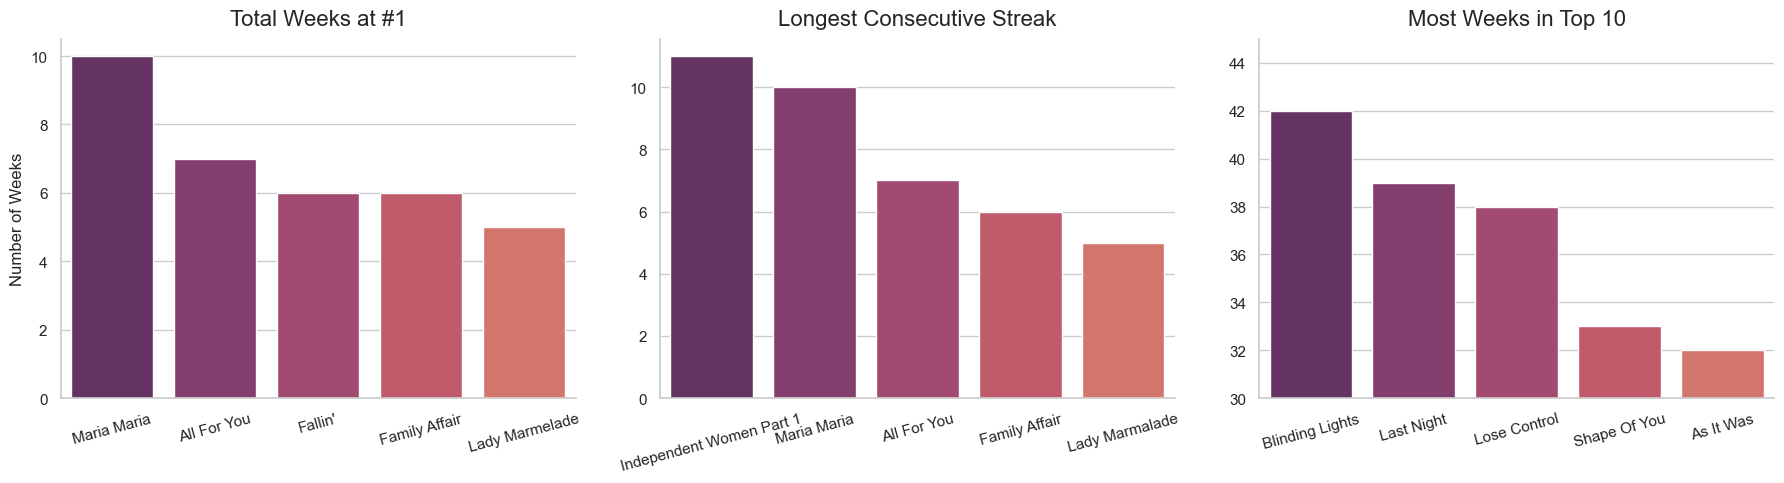

In [72]:

fig_2002, axes = plt.subplots(1, 3, figsize=(18, 5)) 

# fig 1 - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
sns.barplot(
    data=no_1_graph, 
    x="name_track", 
    y="count",
    ax=axes[0],
    hue="name_track", 
    legend=False
)

axes[0].set_title("Total Weeks at #1", fontsize=16, pad=10)
axes[0].set_xlabel("")
axes[0].set_ylabel("Number of Weeks", fontsize=12)


# fig 2 - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -

sns.barplot(
    data=longest_streak_plot, 
    x="name_track", 
    y="count", 
    ax=axes[1],
    hue="name_track",
    legend=False,
)

axes[1].set_title("Longest Consecutive Streak", fontsize=16, pad=10)
axes[1].set_xlabel("")
axes[1].set_ylabel("")


# fig 3 - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -

sns.barplot(
    data=list_top10, 
    x="name_track", 
    y="weeks_at_10", 
    ax=axes[2],
    hue="name_track", 
    legend=False    
)

axes[2].set_title("Most Weeks in Top 10", fontsize=16, pad=10)
axes[2].set_xlabel("")
axes[2].set_ylabel("")
axes[2].set_ylim(30, 45)

for ax in axes:

    ax.tick_params(axis='x', labelrotation=15) 
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

## 3 Build functions
Here I scale the idea to the entire dataset

### Date range
- Selecting the date range
- Calculating local Normalisation Number
- Light cleaning

For all three functions, the initial step is the same. So it's its own function that is to be nested to start the other ones off.

**Local Normalisation Number**
As the Normalisation Number is on a yearly scale, one track can have two scores. To combat a Local score is calculated within the selected date range bo looking at a tracks mean. This will be shortened to lnn.

In [73]:
def date_range (df, start_date, end_date):
    #define date range
    start_date = str(start_date)
    end_date = str(end_date)

    # check logic:
    if start_date > end_date:
        print("⚠️ Error: The start date must come before the end date.")
        return None

    
    #df with selected range
    selected_range = df[(df["chart_week"] >= start_date) & 
                       (df["chart_week"] <= end_date)].copy()

    #adding col to show date range
    selected_range["date_range"] = f"{start_date} to {end_date}"

    #create local normalisation numbers (lnn) from selected date range
    selected_range["lnn_no1"] = selected_range.groupby("track_id")["norm_num_no1"].transform("mean").round(3)
    selected_range["lnn_topten"] = selected_range.groupby("track_id")["norm_num_top10"].transform("mean").round(3)
    
    #check if logic works:
    if selected_range.empty:
        print("⚠️ Warning: No data found for this  date range!")
        return None
        
    print("*" * 35)
    print()
    print(f"Start date entered: {start_date}. DF Data Start: {selected_range['chart_week'].min()}")
    print(f"End date entered: {end_date}. DF Data End: {selected_range['chart_week'].max()}")
    print()

    return selected_range

### Longest rule at #1

In [74]:
def longest_total_rule_1 (selected_range):

    if selected_range is None:
        print("⚠️ Warning: There was a problem with the report during the 'data_range' stage.")
        return 

    
    #filter for list position = 1
    selected_range_no1 = selected_range[selected_range["list_position"] == 1].copy()

    
    #check logic
    if (selected_range_no1["list_position"] > 1).any():
        print("⚠️ Warning: There are list positions other than #1 in df.")
        return None

    
    #count number of weeks at #1 total
    selected_range_no1["weeks_time_no1"] = selected_range_no1.groupby("track_id")["track_id"].transform("size")


    #add normalisation col
    selected_range_no1["score_time_no1"] = round(
        selected_range_no1["weeks_time_no1"] / selected_range_no1["lnn_no1"], 3)

    
    #filter out so each "track_id" appears only only once
    summary_weeks_at1 = (selected_range_no1.drop_duplicates("track_id", keep="first")
                                            .sort_values(["score_time_no1", "weeks_time_no1"], ascending=False)
                                            .reset_index(drop=True)
                        )

    
    #ordering the cols (removing 'chart_week' as this is just one of the weeks it appeared, keeping other "extra" cols in case we need them further)
    cols_to_keep = [
        "date_range", "score_time_no1", "weeks_time_no1", 
        "name_track", "name_artists", "track_id","year_on_chart", 
        "release_date", "lnn_no1", "norm_num_no1", "flag_dupe"
    ]
    
    summary_weeks_at1 = summary_weeks_at1[cols_to_keep]


    print("✅ Total weeks at #1 complete.")
    return summary_weeks_at1

### Longerst consecutive rule at #1

In [75]:
def longest_consecutive_rule_1(selected_range):

    if selected_range is None:
        print("⚠️ Warning: There was a problem with the report during the 'data_range' stage.")
        return 

    
    #filter for list position = 1
    selected_range_no1 = selected_range[selected_range["list_position"] == 1].copy()

    
    #check logic
    if (selected_range_no1["list_position"] > 1).any():
        print("⚠️ Warning: There are list positions other than #1 in df.")
        return None

    
    #sorting on chart_week to get consecutive data
    selected_range_no1 = selected_range_no1.sort_values("chart_week").reset_index(drop=True)

    
    #mask that checks if the next row shares the different/same selected value (here 'track_id')
    selected_range_no1["mask"] = selected_range_no1["track_id"].ne(selected_range_no1["track_id"].shift())

    
    #creating island_id - grouping weeks where track id is the same, cumulative counting. T - change count F - dont
    selected_range_no1["island_id"] = selected_range_no1["mask"].cumsum()

    
    #counting consecutive weeks grouped by island id
    selected_range_no1["weeks_consec_no1"] = selected_range_no1.groupby("island_id")["track_id"].transform("size")

    
    #add normalisation col
    selected_range_no1["score_consec_no1"] = round(
        selected_range_no1["weeks_consec_no1"] / selected_range_no1["lnn_no1"], 3)

    
    #save only the largest concecutive streak for each track
    selected_range_no1 = selected_range_no1.sort_values(["track_id", "score_consec_no1"], ascending=False).drop_duplicates("track_id", keep="first")

    
    #sort and reset index
    summary_weeks_at1 = (selected_range_no1.sort_values(["score_consec_no1", "weeks_consec_no1"], ascending=False)
                                            .reset_index(drop=True)
                        )

    
    #ordering the cols (removing 'chart_week' as this is just one of the weeks it appeared, keeping other "extra" cols in case we need them further)
    cols_to_keep = [
        "date_range", "score_consec_no1", "weeks_consec_no1", 
        "name_track", "name_artists", "track_id","year_on_chart", 
        "release_date", "lnn_no1", "norm_num_no1", "flag_dupe"
    ]
    
    summary_weeks_at1 = summary_weeks_at1[cols_to_keep]

    
    print("✅ Consecutive weeks at #1 complete.")

    return summary_weeks_at1

### Longest time in top 10

In [76]:
def longest_time_top10(selected_range):

    if selected_range is None:
        print("⚠️ Warning: There was a problem with the report during the 'data_range' stage.")
        return 

    
    #extract tracks that has had i) list position #1 and ii) had weeks in top ten
    first_place_list = selected_range[selected_range["list_position"] == 1]["track_id"].unique().tolist()

    hot_top_ten = selected_range[(selected_range["list_position"] <= 10) & 
                                (selected_range["track_id"].isin(first_place_list))].copy()

    
    #count weeks in top ten per track_id
    hot_top_ten["weeks_top10"] = hot_top_ten.groupby("track_id")["track_id"].transform("size")

    
    #add normalisation col
    hot_top_ten["score_top10"] = round(
        hot_top_ten["weeks_top10"] / hot_top_ten["lnn_topten"], 3
    )

    
    #filter out so each 'track_id' appears only once
    summary_weeks_in_top10 = (hot_top_ten.drop_duplicates("track_id")
                                        .sort_values(["score_top10", "weeks_top10"], ascending=False)
                                        .reset_index(drop=True)
                             )

    
    #ordering the cols (removing 'chart_week' as this is just one of the weeks it appeared, keeping other "extra" cols in case we need them further)
    cols_to_keep = [
        "date_range", "score_top10", "weeks_top10", 
        "name_track", "name_artists", "track_id","year_on_chart", 
        "release_date", "lnn_topten", "norm_num_top10", "flag_dupe"
    ]

    summary_weeks_in_top10 = summary_weeks_in_top10[cols_to_keep]
    
    
    print("✅ Top ten complete.")

    return summary_weeks_in_top10

### Weighted analysis (SSI)

In [77]:
def soul_saving_index(df, start_date, end_date):
    selected_range = date_range(df, start_date, end_date)

    if selected_range is None:
        return None

    # perform the different calucations by calling each function
    total_rule_1 = longest_total_rule_1(selected_range)
    consec_rule_1 = longest_consecutive_rule_1(selected_range)
    top_ten_time = longest_time_top10(selected_range)

    # check for errors
    if not total_rule_1["track_id"].is_unique:
        print(f"⚠️ Warning:'track_id' in 'total_rule_1' is not unique")
        return None
        
    if not consec_rule_1["track_id"].is_unique:
        print(f"⚠️ Warning:'track_id' in 'consec_rule_1' is not unique")
        return None

    if not top_ten_time["track_id"].is_unique:
        print(f"⚠️ Warning:'track_id' in 'top_ten_time' is not unique")
        return None

    # merge to master SSI df
    masterSSI = (total_rule_1
                .merge(consec_rule_1[["track_id", "score_consec_no1", "weeks_consec_no1"]], on="track_id", how="left")
                .merge(top_ten_time[["track_id", "score_top10", "weeks_top10", "lnn_topten"]], on="track_id", how="left")
    )

    
    # changing NaN to 0 for calculations
    masterSSI = masterSSI.fillna(0)

    
    # add SSI col, weigted to total = 0.35 / consec = 0.45 / top10 = 0.20
    masterSSI["SSI_score"] = round(
        (masterSSI["score_time_no1"]*0.35) +
        (masterSSI["score_consec_no1"]*0.45) +
        (masterSSI["score_top10"]*0.20), 3
    )

    
    # make her pretty
    master_col_order = [
        "date_range", "SSI_score", "name_track", "name_artists", "track_id", 
        "score_consec_no1", "score_time_no1", "score_top10", 
        "weeks_time_no1", "weeks_consec_no1", "weeks_top10", "year_on_chart",
        "release_date", "lnn_no1", "lnn_topten", "flag_dupe"
    ]
    
    masterSSI = (masterSSI[master_col_order]
                .sort_values(["SSI_score", "weeks_consec_no1", "weeks_time_no1", "weeks_top10"], ascending=False)
                .reset_index(drop=True)
                )

    print()
    print("'And we played the first thing that came to our heads, just so happened to be") 
    print("The best song in the world, it was the best song in the world':")
    print(f"\n✨ {masterSSI.loc[0]['name_track'].title()} by {masterSSI.loc[0]['name_artists'].title()}✨")
    
    #return the truth
    return masterSSI.head(3)

## 4 Finding the Greatest Song in the World

**Which song saved Jack and Kyle?**
- 2000-01-01 to 2002-06-01

**Which song would they have sung?**
- 2009
- 2016
- 2024

Remember, they have the whole back catalouge of excisting songs so we're always starting at 2000-01-01

### 4.1 Running the SSI function on the above mentioned rate ranges

In [78]:
#dates: 2000-01-01 2002-06-01
SSI_2000_2002 = soul_saving_index(df_top10, "2000-01-01", "2002-06-01")

***********************************

Start date entered: 2000-01-01. DF Data Start: 2000-01-01 00:00:00
End date entered: 2002-06-01. DF Data End: 2002-06-01 00:00:00

✅ Total weeks at #1 complete.
✅ Consecutive weeks at #1 complete.
✅ Top ten complete.

'And we played the first thing that came to our heads, just so happened to be
The best song in the world, it was the best song in the world':

✨ Independent Women Part 1 by Destiny'S Child✨


In [79]:
# dates: 2000-01-01 2010-01-01
SSI_2000_2009 = soul_saving_index(df_top10, "2000-01-01", "2010-01-01")

***********************************

Start date entered: 2000-01-01. DF Data Start: 2000-01-01 00:00:00
End date entered: 2010-01-01. DF Data End: 2009-12-26 00:00:00

✅ Total weeks at #1 complete.
✅ Consecutive weeks at #1 complete.
✅ Top ten complete.

'And we played the first thing that came to our heads, just so happened to be
The best song in the world, it was the best song in the world':

✨ Irreplaceable by Beyoncé✨


In [80]:
# dates: 2000-01-01 2017-01-01
SSI_2000_2016 = soul_saving_index(df_top10, "2000-01-01", "2017-01-01")

***********************************

Start date entered: 2000-01-01. DF Data Start: 2000-01-01 00:00:00
End date entered: 2017-01-01. DF Data End: 2016-12-31 00:00:00

✅ Total weeks at #1 complete.
✅ Consecutive weeks at #1 complete.
✅ Top ten complete.

'And we played the first thing that came to our heads, just so happened to be
The best song in the world, it was the best song in the world':

✨ Irreplaceable by Beyoncé✨


In [81]:
# dates: 2000-01-01 2025-01-01
SSI_2000_2024 = soul_saving_index(df_top10, "2000-01-01", "2025-01-01")

***********************************

Start date entered: 2000-01-01. DF Data Start: 2000-01-01 00:00:00
End date entered: 2025-01-01. DF Data End: 2024-10-12 00:00:00

✅ Total weeks at #1 complete.
✅ Consecutive weeks at #1 complete.
✅ Top ten complete.

'And we played the first thing that came to our heads, just so happened to be
The best song in the world, it was the best song in the world':

✨ Irreplaceable by Beyoncé✨


In [82]:
#extracting winners

winners = pd.concat(
    [SSI_2000_2002.iloc[[0]], SSI_2000_2009.iloc[[0]], SSI_2000_2016.iloc[[0]], SSI_2000_2024.iloc[[0]]])

winners

,date_range,SSI_score,name_track,name_artists,track_id,score_consec_no1,score_time_no1,score_top10,weeks_time_no1,weeks_consec_no1,weeks_top10,year_on_chart,release_date,lnn_no1,lnn_topten,flag_dupe
0,2000-01-01 to 2002-06-01,1.204,independent women part 1,destiny's child,0j2wgm8zu6y5qkofgyjv9h,1.281,1.281,0.895,11,11,17,2000,2012-06-19,8.588,19.00,False
0,2000-01-01 to 2010-01-01,1.309,irreplaceable,beyoncé,6rx5il93vz5fkmyvnxvf1r,1.429,1.429,0.831,10,10,16,2006,2007-05-29,7.000,19.25,False
0,2000-01-01 to 2017-01-01,1.309,irreplaceable,beyoncé,6rx5il93vz5fkmyvnxvf1r,1.429,1.429,0.831,10,10,16,2006,2007-05-29,7.000,19.25,False
0,2000-01-01 to 2025-01-01,1.309,irreplaceable,beyoncé,6rx5il93vz5fkmyvnxvf1r,1.429,1.429,0.831,10,10,16,2006,2007-05-29,7.000,19.25,False


### 4.2 What is music made of?

Moving over to look at what makes up the songs that won.

Using Spotify audio information the see what the Devil likes and what has changed over time.

Forming the graphs needed for the article

#### Joining SSI information with Spotify insights

working with the winners dataframe


In [83]:
#merging the spotify information, some clean up

def spotify_merge(df):

    #merging spotify datafram
    df = df.merge(spotify_df, on="track_id", how="left")


    # short date format for readability
    dates_rename = df["date_range"].str.split(" to ", expand=True)

    start_year = dates_rename[0].str[2:4]
    end_year = dates_rename[1].str[2:4]

    df["date_range_short"] = "'" + start_year + " - " + "'" + end_year

    
    #fix naming issue after join
    df = df.rename(columns={"name_track_x": "name_track", "name_artists_x": "name_artists"})


    
    # new col order
    new_order_cols = [
        "date_range_short", "SSI_score", "name_track", "name_artists", "danceability",
        "energy",  "loudness", "acousticness", 
        "valence","key", "mode", "tempo", "track_id", "date_range"
    ]

    df = df[new_order_cols]
    
    return df

In [84]:
winners = spotify_merge(winners)

winners.head()

,date_range_short,SSI_score,name_track,name_artists,danceability,energy,loudness,acousticness,valence,key,mode,tempo,track_id,date_range
0,'00 - '02,1.204,independent women part 1,destiny's child,0.747,0.638,-6.137,0.1070,0.947,6.0,0.0,97.990,0j2wgm8zu6y5qkofgyjv9h,2000-01-01 to 2002-06-01
1,'00 - '10,1.309,irreplaceable,beyoncé,0.447,0.694,-4.637,0.0293,0.509,7.0,0.0,175.868,6rx5il93vz5fkmyvnxvf1r,2000-01-01 to 2010-01-01
2,'00 - '17,1.309,irreplaceable,beyoncé,0.447,0.694,-4.637,0.0293,0.509,7.0,0.0,175.868,6rx5il93vz5fkmyvnxvf1r,2000-01-01 to 2017-01-01
3,'00 - '25,1.309,irreplaceable,beyoncé,0.447,0.694,-4.637,0.0293,0.509,7.0,0.0,175.868,6rx5il93vz5fkmyvnxvf1r,2000-01-01 to 2025-01-01


#### infobox

- key, mode, tempo

In [85]:
key = {
    1.0: "C#",
    2.0: "D",
    6.0: "F#",
    7.0: "G",
}

mode = {
        1.0: "Major",
        0.0: "Minor"
}

def info_box(df):

    # selecting interesting cols
    info_box = df[["date_range_short", "name_track", "name_artists", "key", "mode", "tempo"]].copy()

    # uppercase
    info_box["name_track"] = info_box["name_track"].str.title()
    info_box["name_artists"] = info_box["name_artists"].str.title()
    info_box

    # changing key and mode, rounding tempo
    info_box["key"] = info_box["key"].replace(key)
    info_box["mode"] = info_box["mode"].replace(mode)
    info_box["tempo"] = info_box["tempo"].round()
    
    return info_box

In [86]:
info_box_winners = info_box(winners)

info_box_winners

,date_range_short,name_track,name_artists,key,mode,tempo
0,'00 - '02,Independent Women Part 1,Destiny'S Child,F#,Minor,98.0
1,'00 - '10,Irreplaceable,Beyoncé,G,Minor,176.0
2,'00 - '17,Irreplaceable,Beyoncé,G,Minor,176.0
3,'00 - '25,Irreplaceable,Beyoncé,G,Minor,176.0


#### Prepping the winners for plot

In [87]:
# colour pallet

metric_pallette = {
    "energy": "#d1615d", #red
    "danceability": "#a87c9f", #purple
    "loudness": "#e7ca60", #yellow
    "valence": "#6a9f58", #green
    "acousticness": "#967662", #brown
}

In [88]:
# changing to long format for plotting
anchors = ["date_range_short", "name_track", "track_id"]
metrics = ["energy", "danceability", "loudness", "valence", "acousticness"]

plot_winners_long = pd.melt(winners,
                        id_vars = anchors,
                        value_vars = metrics,
                        var_name = "metric_type",
                        value_name = "value")

plot_winners_long.head()

,date_range_short,name_track,track_id,metric_type,value
0,'00 - '02,independent women part 1,0j2wgm8zu6y5qkofgyjv9h,energy,0.638
1,'00 - '10,irreplaceable,6rx5il93vz5fkmyvnxvf1r,energy,0.694
2,'00 - '17,irreplaceable,6rx5il93vz5fkmyvnxvf1r,energy,0.694
3,'00 - '25,irreplaceable,6rx5il93vz5fkmyvnxvf1r,energy,0.694
4,'00 - '02,independent women part 1,0j2wgm8zu6y5qkofgyjv9h,danceability,0.747


#### plotting the graphs

1) line plot with two y-axes metrics 0-1 / loudness -6 - -3 showing the winner of the different date ranges
2) boxplot of the top 5 in the 2000-2002 date range


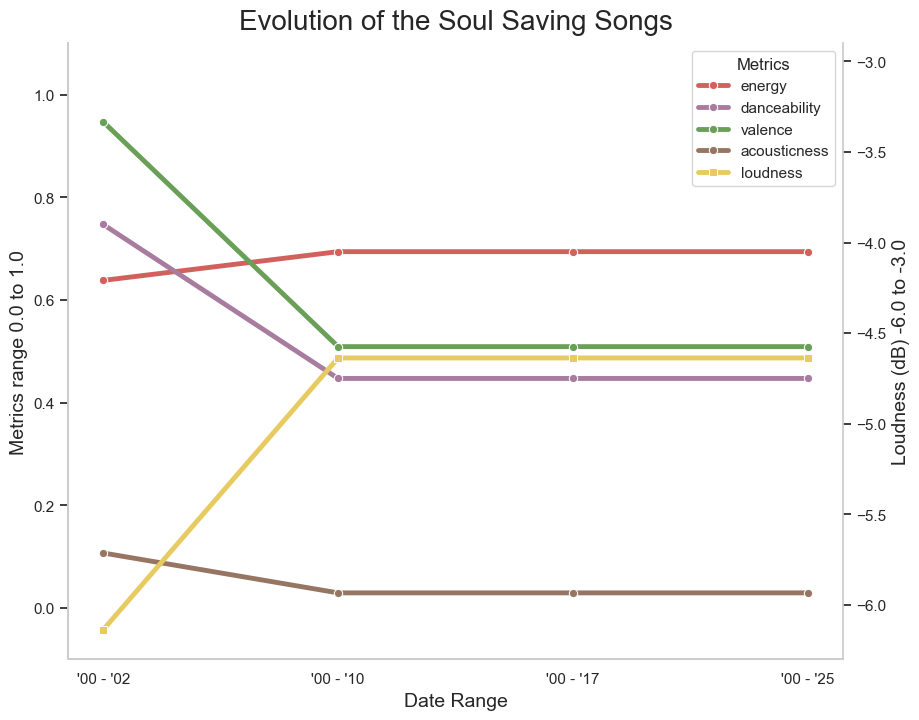

In [89]:

# creating both axes to use
fig_line, ax_line = plt.subplots(figsize=(10, 8))
ax_line.grid(False)

ax_line_loud = ax_line.twinx()
ax_line_loud.grid(False)


# - - - Data - - - - - - - - - - - - - - - - - - - - - - - - - - 

#ax1 (all metrics but loudness)
sns.lineplot(
    data=plot_winners_long[plot_winners_long["metric_type"] != "loudness"],
    x="date_range_short",
    y="value",
    hue="metric_type",
    palette=metric_pallette,
    ax=ax_line,
    marker="o",
    linewidth=3.5,
    #alpha=0.6
)
ax_line.set_ylabel("Metrics range 0.0 to 1.0", fontsize=14)
ax_line.set_xlabel("Date Range", fontsize=14)


#ax2 (loudness)
sns.lineplot(
    data=plot_winners_long[plot_winners_long["metric_type"] == "loudness"],
    x="date_range_short",
    y="value",
    ax=ax_line_loud,
    color="#e7ca60",
    marker="s",
    linewidth=3.5,
    #alpha=0.6,
    label="loudness",
    legend=False
)
ax_line_loud.set_ylabel("Loudness (dB) -6.0 to -3.0", fontsize=14)


# - - - Formatting - - - - - - - - - - - - - - - - - - - - - - - - - -  

# formtting axes
ax_line.set_title("Evolution of the Soul Saving Songs", fontsize=20, pad=10)
ax_line.set_ylim(-0.1, 1.1)
ax_line_loud.set_ylim(-6.3, -2.9)


# formatting legend
lines1, labels1 = ax_line.get_legend_handles_labels()
lines2, labels2 = ax_line_loud.get_legend_handles_labels()
ax_line.legend(lines1 + lines2, labels1 + labels2, title="Metrics", loc="upper right")


sns.despine(ax=ax_line, top=True, right=True)
sns.despine(ax=ax_line_loud, top=True, right=False)
plt.show()

In [90]:
winners

,date_range_short,SSI_score,name_track,name_artists,danceability,energy,loudness,acousticness,valence,key,mode,tempo,track_id,date_range
0,'00 - '02,1.204,independent women part 1,destiny's child,0.747,0.638,-6.137,0.1070,0.947,6.0,0.0,97.990,0j2wgm8zu6y5qkofgyjv9h,2000-01-01 to 2002-06-01
1,'00 - '10,1.309,irreplaceable,beyoncé,0.447,0.694,-4.637,0.0293,0.509,7.0,0.0,175.868,6rx5il93vz5fkmyvnxvf1r,2000-01-01 to 2010-01-01
2,'00 - '17,1.309,irreplaceable,beyoncé,0.447,0.694,-4.637,0.0293,0.509,7.0,0.0,175.868,6rx5il93vz5fkmyvnxvf1r,2000-01-01 to 2017-01-01
3,'00 - '25,1.309,irreplaceable,beyoncé,0.447,0.694,-4.637,0.0293,0.509,7.0,0.0,175.868,6rx5il93vz5fkmyvnxvf1r,2000-01-01 to 2025-01-01


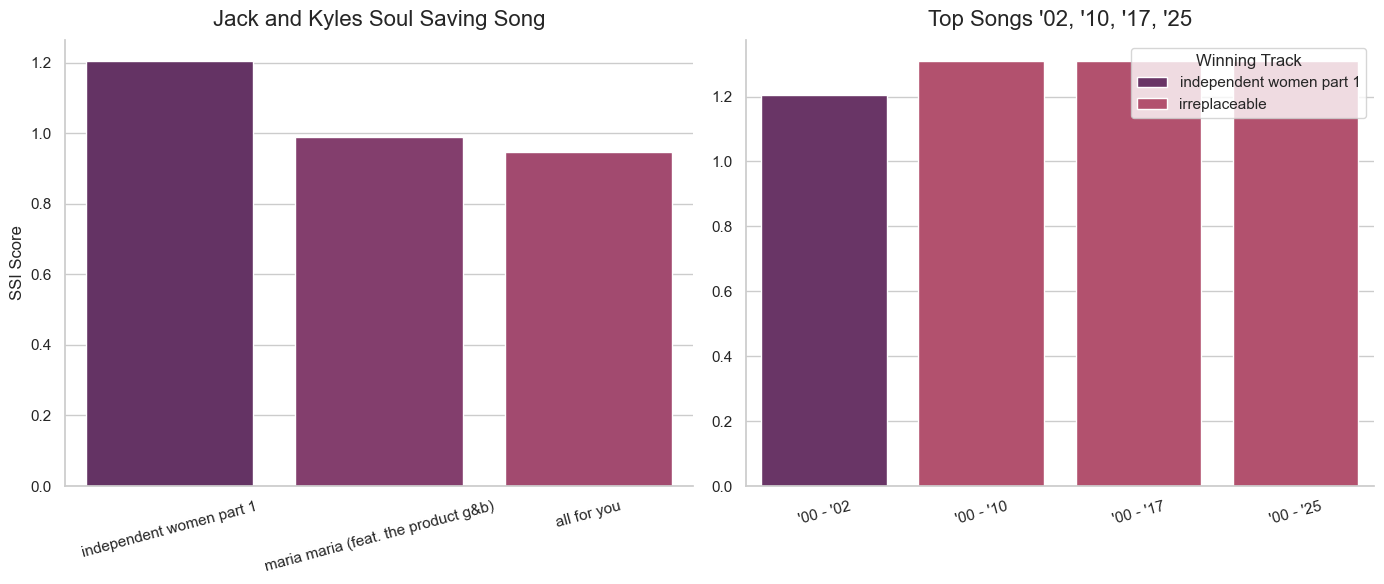

In [91]:
fig_ssi, axes = plt.subplots(1, 2, figsize=(14, 6))
palette_list = sns.color_palette("flare_r", 5)
custom_flare = [palette_list[0], palette_list[2]]

# fig 1 - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
sns.barplot(
    data=SSI_2000_2002.head(), 
    x="name_track", 
    y="SSI_score",
    ax=axes[0],
    hue="name_track", 
    legend=False
)

axes[0].set_title("Jack and Kyles Soul Saving Song", fontsize=16, pad=10)
axes[0].set_xlabel("")
axes[0].set_ylabel("SSI Score", fontsize=12)
axes[0].tick_params(axis='x', labelrotation=15)

sns.despine()

# fig 2 - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
sns.barplot(
    data=winners, 
    x="date_range_short", 
    y="SSI_score",
    ax=axes[1],
    palette=custom_flare,
    hue="name_track", 
    legend=True
)

axes[1].legend(title="Winning Track")
axes[1].set_title("Top Songs '02, '10, '17, '25", fontsize=16, pad=10)
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].tick_params(axis='x', labelrotation=15)


# Design - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
sns.despine()
plt.tight_layout()
plt.show()


# The Editorial:

# **ROLLING BEATS MAGAZINE** 
#### The Greatest Song in the World
##### (A Tenasiuos D Tribute)
____________________________________________________________________________________________________________
*Story by Melina Torstensson*

## The greatest song in the world.

The year is 2002. Life is good, the music produced is excellent, long before the era of algorithmic playlists and AI tunes. The world is a beautiful place. 

Two hitchhikers named Jack and Kyle are walking down a long and lonesome road, when they all of a sudden are stoped by a shine before them. At first glance, it appears to be a deamon, but the swamp tail alludes to him being the Devil himself. He calls upon the two hikers to play the best song in the world, else, he will eat their soul.

The men had no choice, they played the first thing that came to thier heads, and it just so happened to be the best song in the world. The Devil stared, a whip crach went through his tail, the beast was stunned. The men were saved! But what song was it you may ask? Unfortunately, they dont remember. To quote them directly: 


***<center>"Couldn't remember the greatest song in the world [...] It was</center>*** 
***<center>the greatest song in the world alright."</center>***

But could we potentially find out?

***<center>x</center>*** 

Jack and Kyle sing of the greatest song in the world, to our help we have the Billboard Hot 100.

but they are also americans, a people with little knowledge about the outside world. It is possible, that to them, the whole world actually is the USA, meaning, we have to look no further than to the Billboard Hot 100. We also know that the event took place somewhere before June of 2002, so the song cannot have appeard after. 

Next, we need to discuss what exactly makes 'the best song in the world'. Is it the longest rule at #1?, or the longest time in top 10? Longest consicutive rule at #1?

## Top Songs

Depending on which metric we use we see different songs in the top. 

Ps, the scoring is made using a normalisation number (see below), however for reader interest the songs total number of weeks is plotted on the Y-axis. 


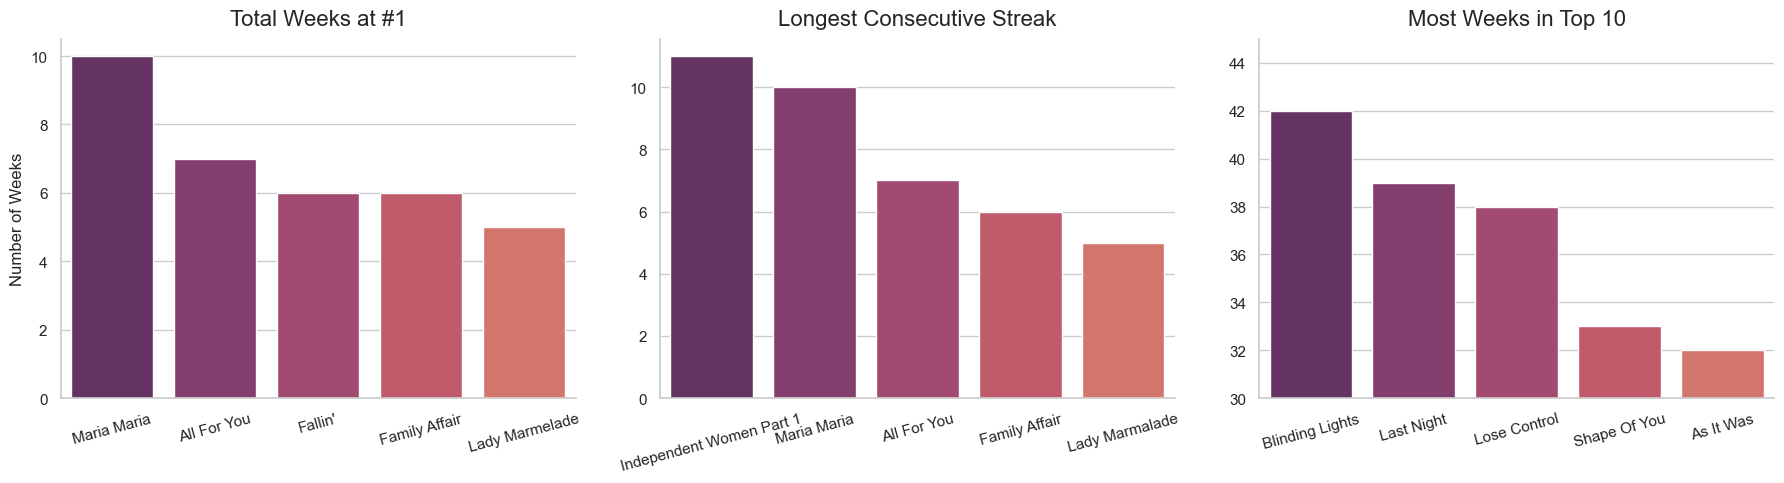

In [92]:
fig_2002

### The Soul Saving Index. (SSI)

The greatest song in the world is the song of songs. It doesnt just make number 1 once, it stays in peoples hearts. It holds it place and it lingers. We never stop singing it. 

The song that saved Kyle and Jack was a combination of all, following a simple mathematical equation - a pythonic function - of the Soul Saving Index (SSI):

 **<center>(Longest time at #1 * 0.35) + (Longest concecutive time at #1 * 0.45) + (Longest time in top10 * 0.20)</center>**
 
 
 ### Solving the streaming mess
Due to the rise of streaming, it has become easier for tracks to hold the #1 spot for much longer periods. 
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
**To make the calculations as precise as possible each year has a "normalisation number"**:

It referes to the maximum times a track held the #1 spot that year. Or the maximal number of weeks spent in top10 that year.
Every equation is then normalised using those numbers.

example: Maria Maria (Santana) held #1 12 times during 2000 which is also the maximum - that years normalisation number is 12.

<center>Maria Maria's normalisation score is 12/12 = 1.0</center>
<center>Say My Name's normalisation score is 10/12 = 0.8</center>
    

Each calculation - total time at #1 / concecutive weeks at #1 / time in top10 has a separate normalisation score.

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
**Each SSI-calculation has a "local" normalisation number**

Since every year has a normalisation number, a track topping the list over more than one year would appear once per year. Instead a "local" normalisation number for the date range is calculated using a track specific mean:

example: How You Remind Me (Nickelback) had a normalisation number of 7 in 2001 / 17 in 2002. Nickelbacks local normalisation number is (7+17)/2= 12. 

### Which song saved Jack and Kyle back in 2002? And which song would have saved them today?

Turns out, maybe against popular believes, the song that save Jack and Kyle was not a rock song. It turns out, the devil at the time was a Destinys Child fan. Who knew right?

If we look to some later dates. We see something very interesting. The Devil seems to have a very special place in his heart for Beyoncé. The queen herself. And not only that! His top song has not changed since 2010. Beyoncés 'Irreplaceable' has a strong hold on the top position. As they say - oncec a banger, always a banger.

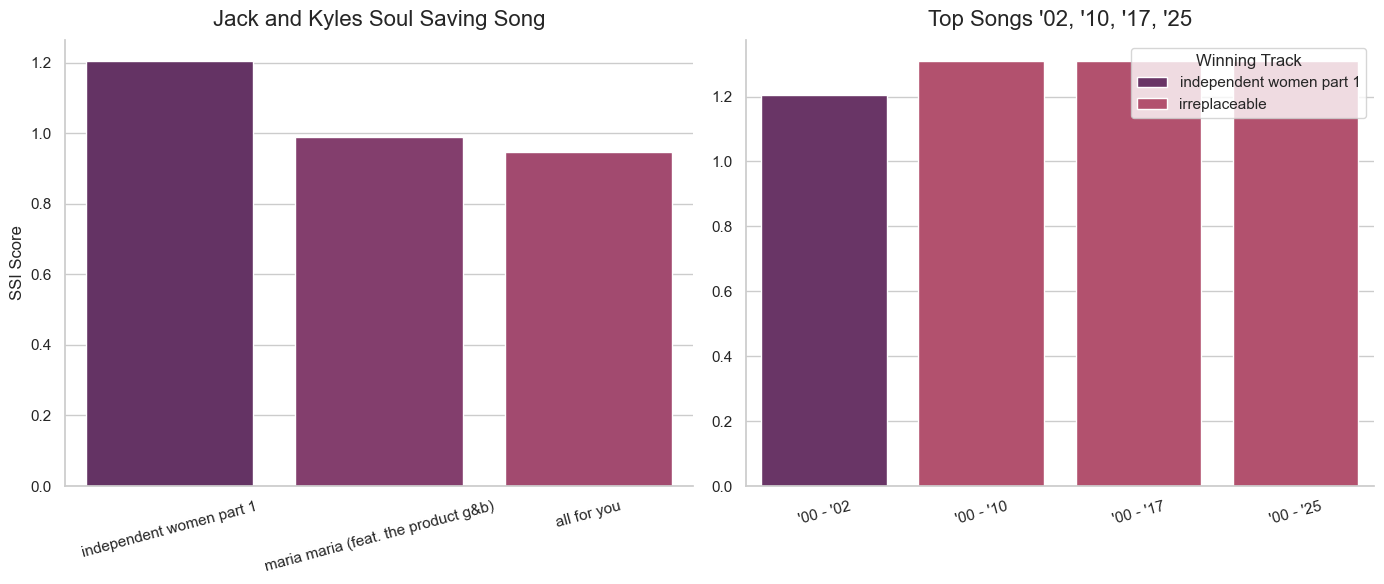

In [93]:
fig_ssi

### What defines a soul saving song? 

The Devil has a sad heart rather than happy. Originally he was into more of a walking pace of song. It may seem as he later picked up the pace, but deep diving (and actually listening to the song) shows that he might have slowed down both tempo and sass to a melancolic 88 bpm.

In [94]:
info_box_winners

,date_range_short,name_track,name_artists,key,mode,tempo
0,'00 - '02,Independent Women Part 1,Destiny'S Child,F#,Minor,98.0
1,'00 - '10,Irreplaceable,Beyoncé,G,Minor,176.0
2,'00 - '17,Irreplaceable,Beyoncé,G,Minor,176.0
3,'00 - '25,Irreplaceable,Beyoncé,G,Minor,176.0


Althou the '02 song being in minor it gives a laid back feeling of being on top of the world. Tempo is moderate, suitable for a playfull dance around in your high heels snaping your fingers. Energy or loudness aren't to high, but does it really need to be when you're just so sure of yourself?

We wont ever know what really happend inbetween '02 and 10', all we know is someting changed. Valence dropped, danceability dropped and loudness rose. Instead of a laid back, careless slide and step down the street, we now walk head down, headphones on. We seem to have froze here. What magical hold does Beyoncés 'Irreplaceable' has on the Devil, making it the greatest song in the world for 15 years?

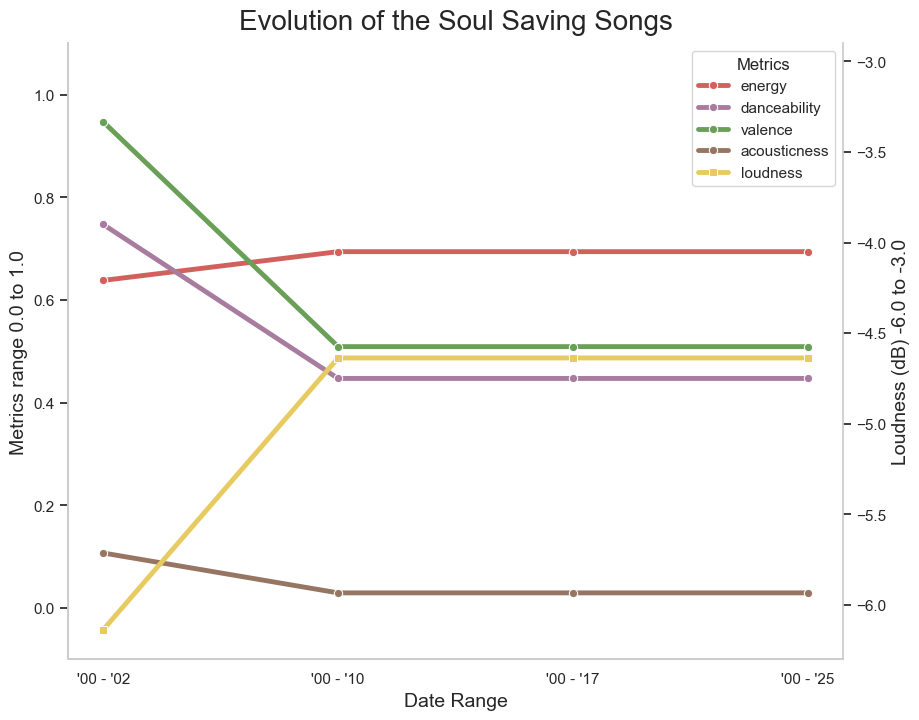

In [95]:
fig_line

### Does the Devil love Beyoncé?

Looks like it. These finding might not be the most groudbreaking posing alot of analysis in how his taste has changed over time, but they also should calm us rather than alarm us. If you ever walk down a long and lonesome road, if ever there shines a shiny light ahead. Beyoncé might well save your life. That lady is truly irreplaceable. 

